# Modelling

**Tujuan**: Melatih dan mengevaluasi 4 algoritma klasifikasi (KNN, Naive Bayes, Logistic Regression, Decision Tree) untuk sentimen & emosi pada ulasan e-commerce.

**Preprocessing**:
1. `normalize_repetitive_chars`
2. `normalize_slang` (kamus alay)
3. `emoji_to_text`
4. `tokenize` (NLTK)
5. `remove_stopwords`
6. `pos_tag` (rule-based)
7. `stem` (Sastrawi)
8. `handle_negation`
9. `extract_emotion_features`

**3 varian fitur**:
- A: TF-IDF only
- B: TF-IDF + Emotion Features
- C: TF-IDF + Emotion Features + Sentiment (hanya untuk klasifikasi emosi)

**Experimental Design (Factorial)**:
- Faktor 1: Algoritma (4 level: KNN, Naive Bayes, Logistic Regression, Decision Tree)
- Faktor 2: Varian Fitur (A, B untuk sentimen; A, B, C untuk emosi)
- Faktor 3: Penanganan Imbalance (tanpa SMOTE / dengan SMOTE)

**Hyperparameter Tuning**: GridSearchCV dengan 5-Fold Stratified Cross-Validation

**Evaluasi**: Accuracy, Precision (Macro), Recall (Macro), F1-Score (Macro), Waktu Inferensi

In [15]:
import pandas as pd
import numpy as np
import re
import json
import time
import itertools
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
import emoji
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42

### Load Data

In [16]:
df = pd.read_csv("PRDECT-ID Dataset.csv")
df["text"] = df["Customer Review"].copy()
df["text-original"] = df["Customer Review"].copy()

print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nSentiment distribution:\n{df['Sentiment'].value_counts()}")
print(f"\nEmotion distribution:\n{df['Emotion'].value_counts()}")

Total rows: 5400
Columns: ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion', 'text', 'text-original']

Sentiment distribution:
Sentiment
Negative    2821
Positive    2579
Name: count, dtype: int64

Emotion distribution:
Emotion
Happy      1770
Sadness    1202
Fear        920
Love        809
Anger       699
Name: count, dtype: int64


### Load Kamus Alay

In [17]:
kamus_df = pd.read_csv("colloquial-indonesian-lexicon.csv")
kamus_valid = kamus_df[kamus_df["In-dictionary"] == 1]
print(f"Total entri: {len(kamus_df)}")
print(f"Entri valid (In-dictionary=1): {len(kamus_valid)}")

slang_dict = {}
for _, row in kamus_valid.iterrows():
    slang = str(row["slang"]).strip().lower()
    formal = str(row["formal"]).strip().lower()
    if slang in slang_dict:
        if len(formal) < len(slang_dict[slang]):
            slang_dict[slang] = formal
    else:
        slang_dict[slang] = formal

print(f"Unique slang entries in dictionary: {len(slang_dict)}")

Total entri: 15006
Entri valid (In-dictionary=1): 13722
Unique slang entries in dictionary: 3451


### Preprocessing Functions

In [18]:
def normalize_repetitive_chars(text: str) -> str:
    text = re.sub(r"(a)\1{2,}", "a", text)
    text = re.sub(r"(i)\1{2,}", "i", text)
    text = re.sub(r"(u)\1{2,}", "u", text)
    text = re.sub(r"(e)\1{2,}", "e", text)
    text = re.sub(r"(o)\1{2,}", "o", text)
    text = re.sub(r"([^aiueo])\1{2,}", r"\1", text)
    return text

def normalize_slang(text: str, slang_dict: dict) -> str:
    words = text.split()
    normalized = []
    for w in words:
        w_lower = w.lower()
        if w_lower in slang_dict:
            normalized.append(slang_dict[w_lower])
        elif w_lower.rstrip(".,!?;:") in slang_dict:
            punct = w[len(w_lower.rstrip(".,!?;:")):]
            normalized.append(slang_dict[w_lower.rstrip(".,!?;:")] + punct)
        else:
            normalized.append(w)
    return " ".join(normalized)

def tokenize(text: str) -> list:
    return word_tokenize(text)

def remove_stopwords(tokens: list) -> list:
    stop_words = set(stopwords.words('indonesian'))
    return [t for t in tokens if t.lower() not in stop_words]

def pos_tag(tokens: list) -> list:
    konjungsi = {'dan', 'atau', 'tetapi', 'namun', 'sedangkan', 'serta',
                 'karena', 'sehingga', 'maka', 'lalu', 'kemudian',
                 'setelah', 'sebelum', 'ketika', 'sementara', 'walaupun',
                 'meskipun', 'jika', 'kalau', 'apabila', 'bahwa'}
    preposisi = {'di', 'ke', 'dari', 'pada', 'dengan', 'untuk', 'bagi',
                 'oleh', 'tentang', 'seperti', 'sebagai', 'tanpa', 'dalam',
                 'antara', 'menurut', 'sampai', 'hingga'}
    hasil = []
    for token in tokens:
        t = token.lower()
        if re.match(r'^[.,!?;:()\[\]{}\"\'\-]$', token):
            hasil.append((token, 'PUNCT'))
        elif re.match(r'^[0-9,.\-]+$', token):
            hasil.append((token, 'NUM'))
        elif t in konjungsi:
            hasil.append((token, 'CONJ'))
        elif t in preposisi:
            hasil.append((token, 'ADP'))
        elif re.match(r'^(me|men|meng|meny|mem|di|ber|bel|ter|per)', t):
            hasil.append((token, 'VERB'))
        elif re.match(r'^(pe|pen|pem|peng|ke)', t) or t.endswith('an') or t.endswith('kan'):
            hasil.append((token, 'NOUN'))
        elif t.endswith('i'):
            hasil.append((token, 'VERB'))
        else:
            hasil.append((token, 'NOUN'))
    return hasil

def stem(tokens: list, stemmer) -> list:
    return [stemmer.stem(t) for t in tokens]

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def emoji_to_text(text: str) -> str:
    return emoji.demojize(text, language='id')

def handle_negation(tokens: list, neg_words: set = None) -> list:
    if neg_words is None:
        neg_words = {
            "tidak", "bukan", "belum", "tak", "ngga",
            "gak", "ga", "tdk", "enggak", "nggak",
            "kagak", "ndak", "ngg"
        }
    result = []
    negate = False
    for w in tokens:
        w_clean = w.lower().strip(".,!?")
        if w_clean in neg_words:
            result.append(w)
            negate = True
        elif negate:
            result.append("NEG_" + w)
            negate = False
        else:
            result.append(w)
    return result

def extract_emotion_features(series: pd.Series) -> pd.DataFrame:
    features = pd.DataFrame(index=series.index)
    features["n_exclamation"] = series.apply(lambda x: x.count("!"))
    features["n_question"] = series.apply(lambda x: x.count("?"))
    features["n_allcaps"] = series.apply(
        lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 2)
    )
    features["n_ellipsis"] = series.apply(lambda x: x.count(".."))
    features["max_char_repeat"] = series.apply(
        lambda x: max(
            (len(list(g)) for _, g in itertools.groupby(str(x).lower())),
            default=0,
        )
    )
    return features

def extract_emotion_features_enhanced(series: pd.Series) -> pd.DataFrame:
    features = pd.DataFrame(index=series.index)

    # Basic features (same as extract_emotion_features)
    features["n_exclamation"] = series.apply(lambda x: x.count("!"))
    features["n_question"] = series.apply(lambda x: x.count("?"))
    features["n_allcaps"] = series.apply(
        lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 2)
    )
    features["n_ellipsis"] = series.apply(lambda x: x.count(".."))
    features["max_char_repeat"] = series.apply(
        lambda x: max(
            (len(list(g)) for _, g in itertools.groupby(str(x).lower())),
            default=0,
        )
    )

    # Additional linguistic features
    features["n_words"] = series.apply(lambda x: len(str(x).split()))
    features["avg_word_len"] = series.apply(
        lambda x: np.mean([len(w) for w in str(x).split()]) if len(str(x).split()) > 0 else 0
    )

    # Intensifiers
    intensifiers = {"sangat", "sekali", "banget", "paling", "amat",
                    "terlalu", "super", "benar", "sungguh", "betul"}
    features["n_intensifiers"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in intensifiers)
    )

    # Positive and negative emoji counts
    pos_emojis = {"\U0001f60d", "\U0001f60a", "\u2764", "\U0001f44d",
                  "\U0001f604", "\U0001f601", "\U0001f970", "\U0001f618",
                  "\U0001f495", "\U0001f496", "\u2728", "\U0001f4af",
                  "\U0001f525", "\U0001f44f", "\U0001f929", "\U0001f389"}
    neg_emojis = {"\U0001f621", "\U0001f620", "\U0001f622", "\U0001f62d",
                  "\U0001f629", "\U0001f62b", "\U0001f61e", "\U0001f641",
                  "\U0001f623", "\U0001f616", "\U0001f614", "\U0001f44e",
                  "\U0001f494"}
    features["n_positive_emoji"] = series.apply(
        lambda x: sum(1 for ch in str(x) if ch in pos_emojis)
    )
    features["n_negative_emoji"] = series.apply(
        lambda x: sum(1 for ch in str(x) if ch in neg_emojis)
    )

    # Pronouns
    first_person = {"aku", "saya", "kami", "kit", "gue", "gw", "akuu"}
    second_person = {"kamu", "anda", "kau", "kakak", "mas", "mbak", "bro", "sis"}
    features["n_pronoun_1st"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in first_person)
    )
    features["n_pronoun_2nd"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in second_person)
    )

    return features

def full_pipeline(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return text
    t = text
    t = normalize_repetitive_chars(t)
    t = normalize_slang(t, slang_dict)
    t = emoji_to_text(t)
    tokens = tokenize(t)
    tokens = remove_stopwords(tokens)
    pos_tags = pos_tag(tokens)
    tokens = stem(tokens, stemmer)
    tokens = handle_negation(tokens)
    return " ".join(tokens)

### Apply Preprocessing Pipeline

In [19]:
print("Applying preprocessing pipeline to all text...")
tic = time.time()
df['text_processed'] = df['Customer Review'].fillna('').apply(full_pipeline)
toc = time.time()
print(f"Preprocessing complete: {len(df)} texts processed in {toc - tic:.2f}s")

Applying preprocessing pipeline to all text...
Preprocessing complete: 5400 texts processed in 484.86s


## Train/Test Split & Feature Engineering

In [ ]:
max_features = 1500

X_raw_original = df['Customer Review'].fillna('')
X_raw_processed = df['text_processed']
y_emo = df['Emotion']
y_sen = df['Sentiment']

X_train_text, X_test_text, X_train_proc, X_test_proc, y_train_emo, y_test_emo, y_train_sen, y_test_sen = train_test_split(
    X_raw_original, X_raw_processed, y_emo, y_sen,
    test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train size: {len(X_train_text)}, Test size: {len(X_test_text)}")

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=max_features)
X_train_vec = vectorizer.fit_transform(X_train_proc)
X_test_vec = vectorizer.transform(X_test_proc)

# Emotion Features (from original text, not processed)
emotion_train = extract_emotion_features(X_train_text)
emotion_test = extract_emotion_features(X_test_text)

# Varian A: TF-IDF only
X_train_a, X_test_a = X_train_vec, X_test_vec

# Varian B: TF-IDF + Emotion Features
X_train_b = hstack([X_train_vec, emotion_train.values])
X_test_b = hstack([X_test_vec, emotion_test.values])

# Varian C: TF-IDF + Emotion Features + Sentiment (untuk emosi saja)
sent_train = (y_train_sen == "Positive").astype(int).values.reshape(-1, 1)
sent_test = (y_test_sen == "Positive").astype(int).values.reshape(-1, 1)
X_train_c = hstack([X_train_vec, emotion_train.values, sent_train])
X_test_c = hstack([X_test_vec, emotion_test.values, sent_test])

print(f"\nFeature variant shapes:")
print(f"  Varian A (TF-IDF only):                  Train {X_train_a.shape}, Test {X_test_a.shape}")
print(f"  Varian B (TF-IDF + Emotion):             Train {X_train_b.shape}, Test {X_test_b.shape}")
print(f"  Varian C (TF-IDF + Emotion + Sentiment): Train {X_train_c.shape}, Test {X_test_c.shape}")

# Distribution check
print(f"\n=== Class Distribution Check ===")
print(f"\nSentiment - Train:")
print(y_train_sen.value_counts().to_string())
print(f"\nSentiment - Test:")
print(y_test_sen.value_counts().to_string())
print(f"\nEmotion - Train:")
print(y_train_emo.value_counts().to_string())
print(f"\nEmotion - Test:")
print(y_test_emo.value_counts().to_string())

# N-Gram Vectorization untuk Improved Emotion
print("\n--- N-Gram TF-IDF Vectorization ---")
vectorizer_ng = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=2)
X_train_vec_ng = vectorizer_ng.fit_transform(X_train_proc)
X_test_vec_ng = vectorizer_ng.transform(X_test_proc)
print(f"N-gram TF-IDF shape: Train {X_train_vec_ng.shape}, Test {X_test_vec_ng.shape}")

# Enhanced Emotion Features (15 fitur)
emotion_train_enh = extract_emotion_features_enhanced(X_train_text)
emotion_test_enh = extract_emotion_features_enhanced(X_test_text)
print(f"Enhanced Emotion Features shape: Train {emotion_train_enh.shape}")
print(f"Enhanced columns: {list(emotion_train_enh.columns)}")

# Variants for Set A (ngram + 5 basic emotion features)
X_train_ng5_a, X_test_ng5_a = X_train_vec_ng, X_test_vec_ng
X_train_ng5_b = hstack([X_train_vec_ng, emotion_train.values])
X_test_ng5_b = hstack([X_test_vec_ng, emotion_test.values])
X_train_ng5_c = hstack([X_train_vec_ng, emotion_train.values, sent_train])
X_test_ng5_c = hstack([X_test_vec_ng, emotion_test.values, sent_test])

# Variants for Set B & C (ngram + 15 enhanced emotion features)
X_train_ng15_a, X_test_ng15_a = X_train_vec_ng, X_test_vec_ng
X_train_ng15_b = hstack([X_train_vec_ng, emotion_train_enh.values])
X_test_ng15_b = hstack([X_test_vec_ng, emotion_test_enh.values])
X_train_ng15_c = hstack([X_train_vec_ng, emotion_train_enh.values, sent_train])
X_test_ng15_c = hstack([X_test_vec_ng, emotion_test_enh.values, sent_test])

print(f"\nNew feature variant shapes:")
print(f"  Set A (ng+basic5):     {X_train_ng5_a.shape}, {X_train_ng5_b.shape}, {X_train_ng5_c.shape}")
print(f"  Set B/C (ng+enhanced): {X_train_ng15_a.shape}, {X_train_ng15_b.shape}, {X_train_ng15_c.shape}")

Train size: 4320, Test size: 1080

Feature variant shapes:
  Varian A (TF-IDF only):                  Train (4320, 1500), Test (1080, 1500)
  Varian B (TF-IDF + Emotion):             Train (4320, 1505), Test (1080, 1505)
  Varian C (TF-IDF + Emotion + Sentiment): Train (4320, 1506), Test (1080, 1506)

=== Class Distribution Check ===

Sentiment - Train:
Sentiment
Negative    2264
Positive    2056

Sentiment - Test:
Sentiment
Negative    557
Positive    523

Emotion - Train:
Emotion
Happy      1414
Sadness     949
Fear        761
Love        642
Anger       554

Emotion - Test:
Emotion
Happy      356
Sadness    253
Love       167
Fear       159
Anger      145

--- N-Gram TF-IDF Vectorization ---
N-gram TF-IDF shape: Train (4320, 3000), Test (1080, 3000)
Enhanced Emotion Features shape: Train (4320, 12)
Enhanced columns: ['n_exclamation', 'n_question', 'n_allcaps', 'n_ellipsis', 'max_char_repeat', 'n_words', 'avg_word_len', 'n_intensifiers', 'n_positive_emoji', 'n_negative_emoji', 'n_pro

## Experimental Design — Factorial Design

### Faktor & Level
| Faktor | Level | Keterangan |
|--------|-------|------------|
| **Algoritma** | 4 | KNN, Naive Bayes, Logistic Regression, Decision Tree |
| **Varian Fitur** | 2 (sentimen) / 3 (emosi) | A, B untuk sentimen; A, B, C untuk emosi |
| **Penanganan Imbalance** | 2 | Tanpa SMOTE, Dengan SMOTE |

### Strategi
1. **GridSearchCV** dengan **5-Fold Stratified K-Fold** untuk mencari hyperparameter terbaik setiap algoritma
2. Evaluasi model terbaik pada **held-out test set** (20% data)
3. Metrik evaluasi: **Accuracy, Precision (Macro), Recall (Macro), F1-Score (Macro), Waktu Inferensi**

In [ ]:
# Parameter Grid untuk setiap algoritma

# Grid dasar
param_grids = {
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    },
    "Naive Bayes": {
        "alpha": [0.01, 0.1, 0.5, 1.0]
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["lbfgs"],
        "max_iter": [1000]
    },
    "Decision Tree": {
        "max_depth": [5, 10, 15, 20, None],
        "criterion": ["gini", "entropy"],
        "min_samples_split": [2, 5, 10]
    }
}

# Grid diperluas
param_grids_ext = {
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"],
        "leaf_size": [20, 30],
        "p": [1, 2]
    },
    "Naive Bayes": {
        "alpha": [0.01, 0.1, 0.5, 1.0],
        "fit_prior": [True, False]
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["saga"],
        "penalty": ["l1", "l2"],
        "max_iter": [1000],
        "class_weight": [None, "balanced"]
    },
    "Decision Tree": {
        "max_depth": [5, 10, 15, 20, None],
        "criterion": ["gini", "entropy"],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 3, 5],
        "class_weight": [None, "balanced"]
    }
}

# Model classes
model_classes = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE)
}

# Experiment Runner Function
def run_experiment(model_name, variant_name, X_train, X_test, y_train, y_test,
                   imbalance, task_type='binary', use_extended_grid=False):
    model_class = model_classes[model_name]
    param_grid = param_grids_ext[model_name] if use_extended_grid else param_grids[model_name]

    # Build pipeline with imbalance handling
    if imbalance == 'smote':
        pipeline = ImbPipeline([
            ('sampler', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
            ('clf', model_class)
        ])
    elif imbalance == 'adasyn':
        from imblearn.over_sampling import ADASYN
        pipeline = ImbPipeline([
            ('sampler', ADASYN(random_state=RANDOM_STATE, n_neighbors=3)),
            ('clf', model_class)
        ])
    else:
        pipeline = ImbPipeline([
            ('clf', model_class)
        ])

    param_grid_prefixed = {f'clf__{k}': v for k, v in param_grid.items()}

    scoring = 'f1_macro' if task_type == 'multiclass' else 'f1'

    # GridSearchCV with 5-Fold Stratified CV
    gs = GridSearchCV(
        pipeline, param_grid_prefixed,
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring, n_jobs=-1, verbose=0
    )

    # Fit model
    tic = time.time()
    gs.fit(X_train, y_train)
    fit_time = time.time() - tic

    # Predict + inference time
    tic = time.time()
    y_pred = gs.predict(X_test)
    infer_time = time.time() - tic

    # Evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    best_params_clean = {k.replace('clf__', ''): v for k, v in gs.best_params_.items()}

    imbalance_label = {'none': 'Tidak', 'smote': 'SMOTE', 'adasyn': 'ADASYN'}.get(imbalance, imbalance)

    return {
        'Algoritma': model_name,
        'Varian': variant_name,
        'Imbalance': imbalance_label,
        'Best Params': str(best_params_clean),
        'CV Score': round(gs.best_score_, 4),
        'Accuracy': round(acc, 4),
        'Precision (Macro)': round(prec, 4),
        'Recall (Macro)': round(rec, 4),
        'F1-Score (Macro)': round(f1, 4),
        'Fit Time (s)': round(fit_time, 2),
        'Inference Time (s)': round(infer_time, 4),
        '_y_pred': y_pred,
        '_best_estimator': gs.best_estimator_
    }

# Experiment Configurations — Original
sentiment_configs = [
    ('A', X_train_a, X_test_a),
    ('B', X_train_b, X_test_b),
]

emotion_configs = [
    ('A', X_train_a, X_test_a),
    ('B', X_train_b, X_test_b),
    ('C', X_train_c, X_test_c),
]

# Experiment Configurations — Improved
# Set A: n-gram (1,2) + 5 basic emotion features
emotion_configs_ng5 = [
    ('A (ng5)', X_train_ng5_a, X_test_ng5_a),
    ('B (ng5)', X_train_ng5_b, X_test_ng5_b),
    ('C (ng5)', X_train_ng5_c, X_test_ng5_c),
]

# Set B & C: n-gram (1,2) + 15 enhanced emotion features
emotion_configs_ng15 = [
    ('A (ng15)', X_train_ng15_a, X_test_ng15_a),
    ('B (ng15)', X_train_ng15_b, X_test_ng15_b),
    ('C (ng15)', X_train_ng15_c, X_test_ng15_c),
]

algorithms = list(model_classes.keys())
smote_options = [False, True]
imbalance_options = ['none', 'smote', 'adasyn']

total_sentiment_experiments = len(algorithms) * len(sentiment_configs) * len(smote_options)
total_emotion_experiments = len(algorithms) * len(emotion_configs) * len(smote_options)
print(f"Total konfigurasi eksperimen:")
print(f"  Sentiment: {total_sentiment_experiments} (4 algoritma x {len(sentiment_configs)} varian x 2 SMOTE)")
print(f"  Emotion:   {total_emotion_experiments} (4 algoritma x {len(emotion_configs)} varian x 2 SMOTE)")
print(f"  Total:     {total_sentiment_experiments + total_emotion_experiments}")

Total konfigurasi eksperimen:
  Sentiment: 16 (4 algoritma x 2 varian x 2 SMOTE)
  Emotion:   24 (4 algoritma x 3 varian x 2 SMOTE)
  Total:     40


## Sentiment Classification — Factorial Experiments

In [22]:
print("=" * 90)
print("SENTIMENT CLASSIFICATION — Factorial Experiment")
print("=" * 90)

results_sentiment = []
best_models_sentiment = {}

total = len(algorithms) * len(sentiment_configs) * len(smote_options)
counter = 0

for algo in algorithms:
    for variant_name, X_tr, X_te in sentiment_configs:
        for use_smote in smote_options:
            counter += 1
            imbalance = 'smote' if use_smote else 'none'
            smote_label = 'w/SMOTE' if use_smote else 'no SMOTE'
            print(f"\n[{counter}/{total}] {algo:20s} | Varian {variant_name} | {smote_label}")
            print("-" * 60)

            result = run_experiment(
                algo, variant_name, X_tr, X_te,
                y_train_sen, y_test_sen,
                imbalance=imbalance, task_type='binary', use_extended_grid=False
            )

            results_sentiment.append({k: v for k, v in result.items() if not k.startswith('_')})
            best_models_sentiment[(algo, variant_name, use_smote)] = {
                'y_pred': result['_y_pred'],
                'best_estimator': result['_best_estimator']
            }

            print(f"  Best Params: {result['Best Params']}")
            print(f"  CV Score:    {result['CV Score']:.4f}")
            print(f"  Accuracy:    {result['Accuracy']:.4f}")
            print(f"  Precision:   {result['Precision (Macro)']:.4f}")
            print(f"  Recall:      {result['Recall (Macro)']:.4f}")
            print(f"  F1 (Macro):  {result['F1-Score (Macro)']:.4f}")
            print(f"  Infer Time:  {result['Inference Time (s)']:.4f}s")

df_results_sentiment = pd.DataFrame(results_sentiment)
print("\n" + "=" * 90)
print("SENTIMENT EXPERIMENTS COMPLETE")
print("=" * 90)
display(df_results_sentiment)

SENTIMENT CLASSIFICATION — Factorial Experiment

[1/16] KNN                  | Varian A | no SMOTE
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
  CV Score:    nan
  Accuracy:    0.6926
  Precision:   0.6997
  Recall:      0.6952
  F1 (Macro):  0.6914
  Infer Time:  0.0701s

[2/16] KNN                  | Varian A | w/SMOTE
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
  CV Score:    nan
  Accuracy:    0.6657
  Precision:   0.7477
  Recall:      0.6745
  F1 (Macro):  0.6422
  Infer Time:  0.0576s

[3/16] KNN                  | Varian B | no SMOTE
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
  CV Score:    nan
  Accuracy:    0.7537
  Precision:   0.7548
  Recall:      0.7546
  F1 (Macro):  0.7537
  Infer Time:

,Algoritma,Varian,Imbalance,Best Params,CV Score,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Fit Time (s),Inference Time (s)
0,KNN,A,Tidak,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",NaN,0.6926,0.6997,0.6952,0.6914,7.13,0.0701
1,KNN,A,SMOTE,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",NaN,0.6657,0.7477,0.6745,0.6422,0.81,0.0576
2,KNN,B,Tidak,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",NaN,0.7537,0.7548,0.7546,0.7537,0.19,0.0548
3,KNN,B,SMOTE,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",NaN,0.6537,0.7044,0.6611,0.6370,0.81,0.0657
4,Naive Bayes,A,Tidak,{'alpha': 0.01},NaN,0.8898,0.8898,0.8896,0.8897,0.08,0.0000
5,Naive Bayes,A,SMOTE,{'alpha': 0.01},NaN,0.8898,0.8897,0.8897,0.8897,0.37,0.0010
6,Naive Bayes,B,Tidak,{'alpha': 0.01},NaN,0.8648,0.8647,0.8647,0.8647,0.08,0.0000
7,Naive Bayes,B,SMOTE,{'alpha': 0.01},NaN,0.8630,0.8628,0.8630,0.8629,0.28,0.0010
8,Logistic Regression,A,Tidak,"{'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}",NaN,0.7954,0.8397,0.7896,0.7861,0.09,0.0000
9,Logistic Regression,A,SMOTE,"{'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}",NaN,0.8676,0.8738,0.8656,0.8665,0.30,0.0015


## Emotion Classification — Factorial Experiments

In [23]:
print("=" * 90)
print("EMOTION CLASSIFICATION — Factorial Experiment")
print("=" * 90)

results_emotion = []
best_models_emotion = {}

total = len(algorithms) * len(emotion_configs) * len(smote_options)
counter = 0

for algo in algorithms:
    for variant_name, X_tr, X_te in emotion_configs:
        for use_smote in smote_options:
            counter += 1
            imbalance = 'smote' if use_smote else 'none'
            smote_label = 'w/SMOTE' if use_smote else 'no SMOTE'
            print(f"\n[{counter}/{total}] {algo:20s} | Varian {variant_name} | {smote_label}")
            print("-" * 60)

            result = run_experiment(
                algo, variant_name, X_tr, X_te,
                y_train_emo, y_test_emo,
                imbalance=imbalance, task_type='multiclass', use_extended_grid=False
            )

            results_emotion.append({k: v for k, v in result.items() if not k.startswith('_')})
            best_models_emotion[(algo, variant_name, use_smote)] = {
                'y_pred': result['_y_pred'],
                'best_estimator': result['_best_estimator']
            }

            print(f"  Best Params: {result['Best Params']}")
            print(f"  CV Score:    {result['CV Score']:.4f}")
            print(f"  Accuracy:    {result['Accuracy']:.4f}")
            print(f"  Precision:   {result['Precision (Macro)']:.4f}")
            print(f"  Recall:      {result['Recall (Macro)']:.4f}")
            print(f"  F1 (Macro):  {result['F1-Score (Macro)']:.4f}")
            print(f"  Infer Time:  {result['Inference Time (s)']:.4f}s")

df_results_emotion = pd.DataFrame(results_emotion)
print("\n" + "=" * 90)
print("EMOTION EXPERIMENTS COMPLETE")
print("=" * 90)
display(df_results_emotion)

EMOTION CLASSIFICATION — Factorial Experiment

[1/24] KNN                  | Varian A | no SMOTE
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  CV Score:    0.3787
  Accuracy:    0.3991
  Precision:   0.3826
  Recall:      0.3725
  F1 (Macro):  0.3657
  Infer Time:  0.0526s

[2/24] KNN                  | Varian A | w/SMOTE
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  CV Score:    0.4099
  Accuracy:    0.4167
  Precision:   0.4353
  Recall:      0.4376
  F1 (Macro):  0.4087
  Infer Time:  0.0889s

[3/24] KNN                  | Varian B | no SMOTE
------------------------------------------------------------
  Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
  CV Score:    0.4457
  Accuracy:    0.4880
  Precision:   0.4490
  Recall:      0.4373
  F1 (Macro):  0.4395
  I

,Algoritma,Varian,Imbalance,Best Params,CV Score,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Fit Time (s),Inference Time (s)
0,KNN,A,Tidak,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.3787,0.3991,0.3826,0.3725,0.3657,1.55,0.0526
1,KNN,A,SMOTE,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.4099,0.4167,0.4353,0.4376,0.4087,2.40,0.0889
2,KNN,B,Tidak,"{'metric': 'manhattan', 'n_neighbors': 9, 'wei...",0.4457,0.4880,0.4490,0.4373,0.4395,1.73,0.0816
3,KNN,B,SMOTE,"{'metric': 'manhattan', 'n_neighbors': 9, 'wei...",0.4224,0.4509,0.4214,0.4124,0.4040,3.00,0.2665
4,KNN,C,Tidak,"{'metric': 'euclidean', 'n_neighbors': 9, 'wei...",0.5565,0.6102,0.5591,0.5395,0.5440,1.93,0.0629
5,KNN,C,SMOTE,"{'metric': 'manhattan', 'n_neighbors': 5, 'wei...",0.5396,0.6111,0.5740,0.5596,0.5580,3.48,0.5020
6,Naive Bayes,A,Tidak,{'alpha': 0.1},0.5041,0.5759,0.5518,0.5091,0.5176,0.51,0.0000
7,Naive Bayes,A,SMOTE,{'alpha': 1.0},0.5407,0.5991,0.5612,0.5664,0.5629,1.05,0.0000
8,Naive Bayes,B,Tidak,{'alpha': 0.1},0.5028,0.5685,0.5593,0.4955,0.5043,0.09,0.0010
9,Naive Bayes,B,SMOTE,{'alpha': 0.5},0.5335,0.5713,0.5525,0.5269,0.5272,0.40,0.0010


## Improved Emotion Classification — Feature Engineering Experiments

### Set Eksperimen
| Set | TF-IDF | Emotion Features | Grid | Imbalance |
|-----|--------|-----------------|------|-----------|
| **Set A** | n-gram (1,2), 3000 | Basic (5 fitur) | Base | none, smote |
| **Set B** | n-gram (1,2), 3000 | Enhanced (15 fitur) | Base | none, smote, adasyn |
| **Set C** | n-gram (1,2), 3000 | Enhanced (15 fitur) | Extended | none, smote, adasyn |

In [24]:
print("=" * 90)
print("SET A — N-Gram TF-IDF + Basic Emotion Features (5)")
print("=" * 90)

results_emo_ng5 = []
best_emo_ng5 = {}

total = len(algorithms) * len(emotion_configs_ng5) * len(smote_options)
counter = 0

for algo in algorithms:
    for variant_name, X_tr, X_te in emotion_configs_ng5:
        for use_smote in smote_options:
            counter += 1
            imbalance = 'smote' if use_smote else 'none'
            label = 'w/SMOTE' if use_smote else 'no SMOTE'
            print(f"\n[{counter}/{total}] {algo:20s} | {variant_name:10s} | {label}")
            print("-" * 60)

            result = run_experiment(
                algo, variant_name, X_tr, X_te,
                y_train_emo, y_test_emo,
                imbalance=imbalance, task_type='multiclass', use_extended_grid=False
            )

            results_emo_ng5.append({k: v for k, v in result.items() if not k.startswith('_')})
            best_emo_ng5[(algo, variant_name, use_smote)] = {
                'y_pred': result['_y_pred'],
                'best_estimator': result['_best_estimator']
            }

            print(f"  Best Params: {result['Best Params']}")
            print(f"  CV Score:    {result['CV Score']:.4f}")
            print(f"  Accuracy:    {result['Accuracy']:.4f}")
            print(f"  Precision:   {result['Precision (Macro)']:.4f}")
            print(f"  Recall:      {result['Recall (Macro)']:.4f}")
            print(f"  F1 (Macro):  {result['F1-Score (Macro)']:.4f}")
            print(f"  Infer Time:  {result['Inference Time (s)']:.4f}s")

df_results_emo_ng5 = pd.DataFrame(results_emo_ng5)
print("\n" + "=" * 90)
print("SET A COMPLETE")
print("=" * 90)
display(df_results_emo_ng5)

SET A — N-Gram TF-IDF + Basic Emotion Features (5)

[1/24] KNN                  | A (ng5)    | no SMOTE
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  CV Score:    0.3344
  Accuracy:    0.3583
  Precision:   0.3571
  Recall:      0.3450
  F1 (Macro):  0.3331
  Infer Time:  0.0741s

[2/24] KNN                  | A (ng5)    | w/SMOTE
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  CV Score:    0.3834
  Accuracy:    0.3954
  Precision:   0.4356
  Recall:      0.4298
  F1 (Macro):  0.3917
  Infer Time:  0.1028s

[3/24] KNN                  | B (ng5)    | no SMOTE
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
  CV Score:    0.4611
  Accuracy:    0.5093
  Precision:   0.4730
  Recall:      0.4552
  F1 (Macro):

,Algoritma,Varian,Imbalance,Best Params,CV Score,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Fit Time (s),Inference Time (s)
0,KNN,A (ng5),Tidak,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.3344,0.3583,0.3571,0.3450,0.3331,3.10,0.0741
1,KNN,A (ng5),SMOTE,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.3834,0.3954,0.4356,0.4298,0.3917,3.52,0.1028
2,KNN,B (ng5),Tidak,"{'metric': 'euclidean', 'n_neighbors': 11, 'we...",0.4611,0.5093,0.4730,0.4552,0.4596,5.35,0.0576
3,KNN,B (ng5),SMOTE,"{'metric': 'manhattan', 'n_neighbors': 5, 'wei...",0.4002,0.4278,0.4196,0.4110,0.4066,11.55,1.1903
4,KNN,C (ng5),Tidak,"{'metric': 'euclidean', 'n_neighbors': 9, 'wei...",0.5563,0.6231,0.5762,0.5598,0.5641,7.84,0.0667
5,KNN,C (ng5),SMOTE,"{'metric': 'manhattan', 'n_neighbors': 5, 'wei...",0.5229,0.5898,0.5514,0.5396,0.5372,9.24,0.4617
6,Naive Bayes,A (ng5),Tidak,{'alpha': 0.1},0.5403,0.5741,0.5396,0.5088,0.5150,0.14,0.0010
7,Naive Bayes,A (ng5),SMOTE,{'alpha': 1.0},0.5607,0.6000,0.5648,0.5688,0.5662,0.40,0.0000
8,Naive Bayes,B (ng5),Tidak,{'alpha': 0.1},0.5353,0.5750,0.5575,0.5120,0.5205,0.12,0.0010
9,Naive Bayes,B (ng5),SMOTE,{'alpha': 0.5},0.5560,0.5731,0.5516,0.5326,0.5309,0.42,0.0010


In [25]:
print("=" * 90)
print("SET B — N-Gram TF-IDF + Enhanced Emotion Features (15) + Base Grid")
print("=" * 90)

results_emo_ng15_base = []
best_emo_ng15_base = {}

total = len(algorithms) * len(emotion_configs_ng15) * len(imbalance_options)
counter = 0

for algo in algorithms:
    for variant_name, X_tr, X_te in emotion_configs_ng15:
        for imb in imbalance_options:
            counter += 1
            print(f"\n[{counter}/{total}] {algo:20s} | {variant_name:10s} | {imb}")
            print("-" * 60)

            result = run_experiment(
                algo, variant_name, X_tr, X_te,
                y_train_emo, y_test_emo,
                imbalance=imb, task_type='multiclass', use_extended_grid=False
            )

            results_emo_ng15_base.append({k: v for k, v in result.items() if not k.startswith('_')})
            best_emo_ng15_base[(algo, variant_name, imb)] = {
                'y_pred': result['_y_pred'],
                'best_estimator': result['_best_estimator']
            }

            print(f"  Best Params: {result['Best Params']}")
            print(f"  CV Score:    {result['CV Score']:.4f}")
            print(f"  Accuracy:    {result['Accuracy']:.4f}")
            print(f"  Precision:   {result['Precision (Macro)']:.4f}")
            print(f"  Recall:      {result['Recall (Macro)']:.4f}")
            print(f"  F1 (Macro):  {result['F1-Score (Macro)']:.4f}")
            print(f"  Infer Time:  {result['Inference Time (s)']:.4f}s")

df_results_emo_ng15_base = pd.DataFrame(results_emo_ng15_base)
print("\n" + "=" * 90)
print("SET B COMPLETE")
print("=" * 90)
display(df_results_emo_ng15_base)

SET B — N-Gram TF-IDF + Enhanced Emotion Features (15) + Base Grid

[1/36] KNN                  | A (ng15)   | none
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  CV Score:    0.3344
  Accuracy:    0.3583
  Precision:   0.3571
  Recall:      0.3450
  F1 (Macro):  0.3331
  Infer Time:  0.0521s

[2/36] KNN                  | A (ng15)   | smote
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  CV Score:    0.3834
  Accuracy:    0.3954
  Precision:   0.4356
  Recall:      0.4298
  F1 (Macro):  0.3917
  Infer Time:  0.0845s

[3/36] KNN                  | A (ng15)   | adasyn
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  CV Score:    0.3697
  Accuracy:    0.3731
  Precision:   0.4159
  Recall:      0.4117
  F1 (

,Algoritma,Varian,Imbalance,Best Params,CV Score,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Fit Time (s),Inference Time (s)
0,KNN,A (ng15),Tidak,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.3344,0.3583,0.3571,0.3450,0.3331,2.51,0.0521
1,KNN,A (ng15),SMOTE,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.3834,0.3954,0.4356,0.4298,0.3917,2.42,0.0845
2,KNN,A (ng15),ADASYN,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.3697,0.3731,0.4159,0.4117,0.3688,4.11,0.0951
3,KNN,B (ng15),Tidak,"{'metric': 'manhattan', 'n_neighbors': 11, 'we...",0.3753,0.4222,0.4572,0.3865,0.3884,2.50,0.2084
4,KNN,B (ng15),SMOTE,"{'metric': 'manhattan', 'n_neighbors': 11, 'we...",0.3753,0.4222,0.4572,0.3865,0.3884,4.03,0.3599
5,KNN,B (ng15),ADASYN,"{'metric': 'manhattan', 'n_neighbors': 11, 'we...",0.3753,0.4222,0.4572,0.3865,0.3884,5.63,0.3079
6,KNN,C (ng15),Tidak,"{'metric': 'manhattan', 'n_neighbors': 7, 'wei...",0.4785,0.5620,0.5312,0.4864,0.4838,2.17,0.1566
7,KNN,C (ng15),SMOTE,"{'metric': 'manhattan', 'n_neighbors': 7, 'wei...",0.4785,0.5620,0.5312,0.4864,0.4838,15.98,1.4912
8,KNN,C (ng15),ADASYN,"{'metric': 'manhattan', 'n_neighbors': 7, 'wei...",0.4785,0.5620,0.5312,0.4864,0.4838,9.86,1.2378
9,Naive Bayes,A (ng15),Tidak,{'alpha': 0.1},0.5403,0.5741,0.5396,0.5088,0.5150,0.33,0.0010


In [26]:
print("=" * 90)
print("SET C — N-Gram TF-IDF + Enhanced Emotion Features (15) + Extended Grid")
print("=" * 90)

results_emo_ng15_ext = []
best_emo_ng15_ext = {}

total = len(algorithms) * len(emotion_configs_ng15) * len(imbalance_options)
counter = 0

for algo in algorithms:
    for variant_name, X_tr, X_te in emotion_configs_ng15:
        for imb in imbalance_options:
            counter += 1
            print(f"\n[{counter}/{total}] {algo:20s} | {variant_name:10s} | {imb}")
            print("-" * 60)

            result = run_experiment(
                algo, variant_name, X_tr, X_te,
                y_train_emo, y_test_emo,
                imbalance=imb, task_type='multiclass', use_extended_grid=True
            )

            results_emo_ng15_ext.append({k: v for k, v in result.items() if not k.startswith('_')})
            best_emo_ng15_ext[(algo, variant_name, imb)] = {
                'y_pred': result['_y_pred'],
                'best_estimator': result['_best_estimator']
            }

            print(f"  Best Params: {result['Best Params']}")
            print(f"  CV Score:    {result['CV Score']:.4f}")
            print(f"  Accuracy:    {result['Accuracy']:.4f}")
            print(f"  Precision:   {result['Precision (Macro)']:.4f}")
            print(f"  Recall:      {result['Recall (Macro)']:.4f}")
            print(f"  F1 (Macro):  {result['F1-Score (Macro)']:.4f}")
            print(f"  Infer Time:  {result['Inference Time (s)']:.4f}s")

df_results_emo_ng15_ext = pd.DataFrame(results_emo_ng15_ext)
print("\n" + "=" * 90)
print("SET C COMPLETE")
print("=" * 90)
display(df_results_emo_ng15_ext)

SET C — N-Gram TF-IDF + Enhanced Emotion Features (15) + Extended Grid

[1/36] KNN                  | A (ng15)   | none
------------------------------------------------------------
  Best Params: {'leaf_size': 20, 'metric': 'euclidean', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
  CV Score:    0.3344
  Accuracy:    0.3583
  Precision:   0.3571
  Recall:      0.3450
  F1 (Macro):  0.3331
  Infer Time:  0.0557s

[2/36] KNN                  | A (ng15)   | smote
------------------------------------------------------------
  Best Params: {'leaf_size': 20, 'metric': 'euclidean', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
  CV Score:    0.3834
  Accuracy:    0.3954
  Precision:   0.4356
  Recall:      0.4298
  F1 (Macro):  0.3917
  Infer Time:  0.0967s

[3/36] KNN                  | A (ng15)   | adasyn
------------------------------------------------------------
  Best Params: {'leaf_size': 20, 'metric': 'euclidean', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
  CV Score:    

,Algoritma,Varian,Imbalance,Best Params,CV Score,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Fit Time (s),Inference Time (s)
0,KNN,A (ng15),Tidak,"{'leaf_size': 20, 'metric': 'euclidean', 'n_ne...",0.3344,0.3583,0.3571,0.3450,0.3331,6.58,0.0557
1,KNN,A (ng15),SMOTE,"{'leaf_size': 20, 'metric': 'euclidean', 'n_ne...",0.3834,0.3954,0.4356,0.4298,0.3917,19.48,0.0967
2,KNN,A (ng15),ADASYN,"{'leaf_size': 20, 'metric': 'euclidean', 'n_ne...",0.3697,0.3731,0.4159,0.4117,0.3688,26.33,0.1704
3,KNN,B (ng15),Tidak,"{'leaf_size': 20, 'metric': 'manhattan', 'n_ne...",0.3753,0.4222,0.4572,0.3865,0.3884,10.24,0.2577
4,KNN,B (ng15),SMOTE,"{'leaf_size': 20, 'metric': 'manhattan', 'n_ne...",0.3753,0.4222,0.4572,0.3865,0.3884,14.67,0.2747
5,KNN,B (ng15),ADASYN,"{'leaf_size': 20, 'metric': 'manhattan', 'n_ne...",0.3753,0.4222,0.4572,0.3865,0.3884,20.87,0.2916
6,KNN,C (ng15),Tidak,"{'leaf_size': 20, 'metric': 'manhattan', 'n_ne...",0.4785,0.5620,0.5312,0.4864,0.4838,30.53,0.2349
7,KNN,C (ng15),SMOTE,"{'leaf_size': 20, 'metric': 'manhattan', 'n_ne...",0.4785,0.5620,0.5312,0.4864,0.4838,38.88,0.7158
8,KNN,C (ng15),ADASYN,"{'leaf_size': 20, 'metric': 'manhattan', 'n_ne...",0.4785,0.5620,0.5312,0.4864,0.4838,32.12,0.4188
9,Naive Bayes,A (ng15),Tidak,"{'alpha': 1.0, 'fit_prior': False}",0.5587,0.6000,0.5663,0.5478,0.5540,0.15,0.0000


## Results Summary & Best Model Selection

### Perbandingan Hasil Emotion — Original vs Improved

| Set | Deskripsi |
|-----|-----------|
| **Original** | Unigram TF-IDF + 5 basic features |
| **Set A** | N-gram TF-IDF + 5 basic features |
| **Set B** | N-gram TF-IDF + 15 enhanced features |
| **Set C** | N-gram TF-IDF + 15 enhanced features + Extended Grid + ADASYN |

Cari F1-Score (Macro) tertinggi dari setiap set untuk melihat improvement.


SENTIMENT — Ranked by F1-Score (Macro)


,Algoritma,Varian,Imbalance,Best Params,CV Score,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Fit Time (s),Inference Time (s)
0,Naive Bayes,A,SMOTE,{'alpha': 0.01},NaN,0.8898,0.8897,0.8897,0.8897,0.37,0.0010
1,Naive Bayes,A,Tidak,{'alpha': 0.01},NaN,0.8898,0.8898,0.8896,0.8897,0.08,0.0000
2,Logistic Regression,A,SMOTE,"{'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}",NaN,0.8676,0.8738,0.8656,0.8665,0.30,0.0015
3,Naive Bayes,B,Tidak,{'alpha': 0.01},NaN,0.8648,0.8647,0.8647,0.8647,0.08,0.0000
4,Naive Bayes,B,SMOTE,{'alpha': 0.01},NaN,0.8630,0.8628,0.8630,0.8629,0.28,0.0010
5,Logistic Regression,B,SMOTE,"{'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}",NaN,0.8213,0.8252,0.8195,0.8200,0.45,0.0010
6,Logistic Regression,A,Tidak,"{'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}",NaN,0.7954,0.8397,0.7896,0.7861,0.09,0.0000
7,Logistic Regression,B,Tidak,"{'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}",NaN,0.7796,0.8083,0.7747,0.7721,0.25,0.0000
8,KNN,B,Tidak,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",NaN,0.7537,0.7548,0.7546,0.7537,0.19,0.0548
9,Decision Tree,B,SMOTE,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",NaN,0.7630,0.7993,0.7573,0.7527,2.12,0.0000



EMOTION — Ranked by F1-Score (Macro)


,Algoritma,Varian,Imbalance,Best Params,CV Score,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Fit Time (s),Inference Time (s)
0,Logistic Regression,C,SMOTE,"{'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.6461,0.6870,0.6562,0.6492,0.6481,6.99,0.0010
1,Logistic Regression,C,Tidak,"{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.6337,0.6880,0.6519,0.6250,0.6320,9.38,0.0000
2,Logistic Regression,B,SMOTE,"{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.5958,0.6361,0.6067,0.6111,0.6076,19.57,0.0000
3,Decision Tree,C,Tidak,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.5911,0.6426,0.5968,0.5928,0.5938,10.11,0.0010
4,Logistic Regression,B,Tidak,"{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.5781,0.6398,0.6200,0.5821,0.5925,12.87,0.0010
5,Decision Tree,C,SMOTE,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.6062,0.6269,0.5788,0.5791,0.5771,7.47,0.0010
6,Naive Bayes,C,SMOTE,{'alpha': 0.5},0.5752,0.6352,0.6063,0.5763,0.5765,0.35,0.0010
7,Logistic Regression,A,SMOTE,"{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.5689,0.6019,0.5659,0.5716,0.5677,1.32,0.0015
8,Logistic Regression,A,Tidak,"{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.5654,0.6167,0.5869,0.5565,0.5648,0.71,0.0010
9,Naive Bayes,A,SMOTE,{'alpha': 1.0},0.5407,0.5991,0.5612,0.5664,0.5629,1.05,0.0000



FACTORIAL ANALYSIS — F1-Score (Macro) per Faktor

--- Sentiment: F1-Score (Macro) ---


Varian                    A               B        
Imbalance             SMOTE   Tidak   SMOTE   Tidak
Algoritma                                          
Decision Tree        0.7525  0.7512  0.7527  0.7512
KNN                  0.6422  0.6914  0.6370  0.7537
Logistic Regression  0.8665  0.7861  0.8200  0.7721
Naive Bayes          0.8897  0.8897  0.8629  0.8647


--- Emotion: F1-Score (Macro) ---


Varian                    A               B               C        
Imbalance             SMOTE   Tidak   SMOTE   Tidak   SMOTE   Tidak
Algoritma                                                          
Decision Tree        0.4659  0.4380  0.4729  0.4635  0.5771  0.5938
KNN                  0.4087  0.3657  0.4040  0.4395  0.5580  0.5440
Logistic Regression  0.5677  0.5648  0.6076  0.5925  0.6481  0.6320
Naive Bayes          0.5629  0.5176  0.5272  0.5043  0.5765  0.5520


BEST OVERALL MODELS

>>> SENTIMENT <<<
  Model:      Naive Bayes
  Varian:     A
  Imbalance:  SMOTE
  Best Params: {'alpha': 0.01}
  CV Score:   nan
  Accuracy:   0.8898
  Precision:  0.8897
  Recall:     0.8897
  F1 (Macro): 0.8897
  Infer Time: 0.001s

>>> EMOTION <<<
  Model:      Logistic Regression
  Varian:     C
  Imbalance:  SMOTE
  Best Params: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
  CV Score:   0.6461
  Accuracy:   0.687
  Precision:  0.6562
  Recall:     0.6492
  F1 (Macro): 0.6481
  Infer Time: 0.001s


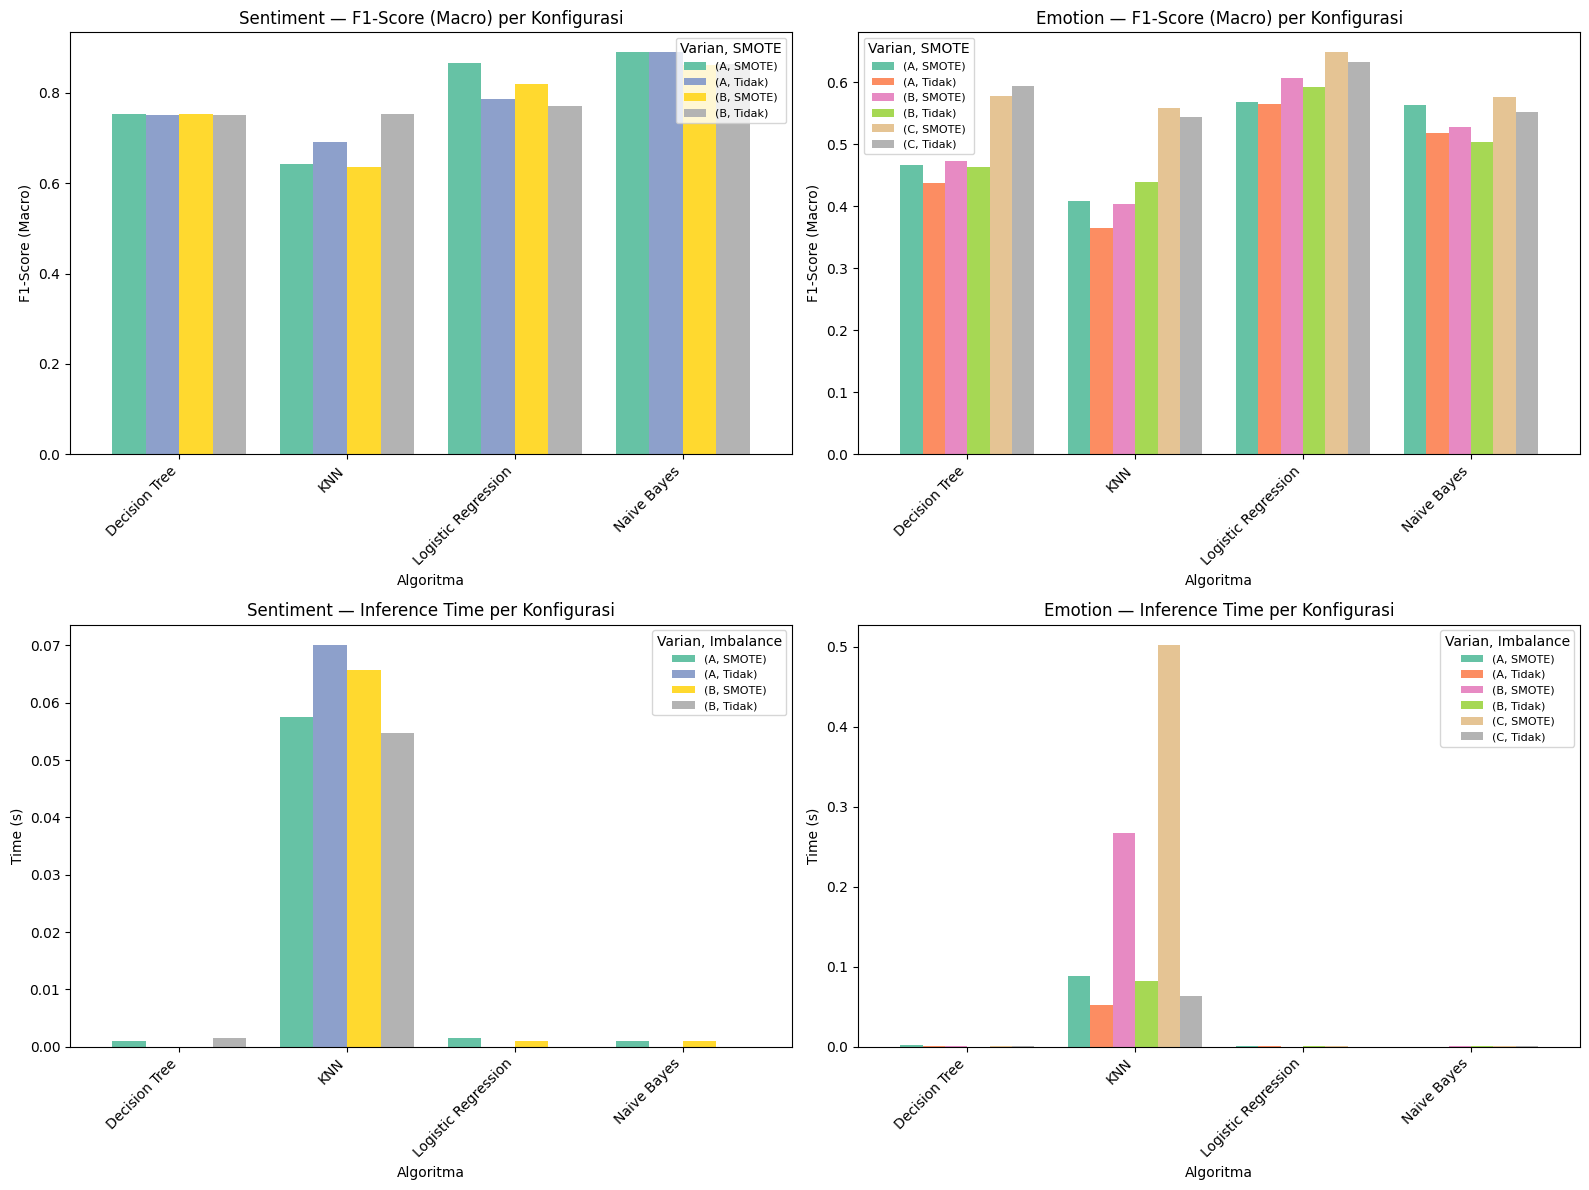


PERBANDINGAN EMOTION: ORIGINAL vs IMPROVED


,Set,Best F1-Macro
0,Original,0.6481
1,Set A (ng+basic),0.6568
2,Set B (ng+enhanced),0.6670
3,Set C (ng+enhanced+ext),0.6501



--- Best per Algorithm (across all configurations) ---

Original:
  Logistic Regression  | C          | SMOTE    | F1: 0.6481

Set A:
  Logistic Regression  | C (ng5)    | SMOTE    | F1: 0.6568

Set B:
  Logistic Regression  | C (ng15)   | SMOTE    | F1: 0.6670

Set C:
  Logistic Regression  | C (ng15)   | ADASYN   | F1: 0.6501


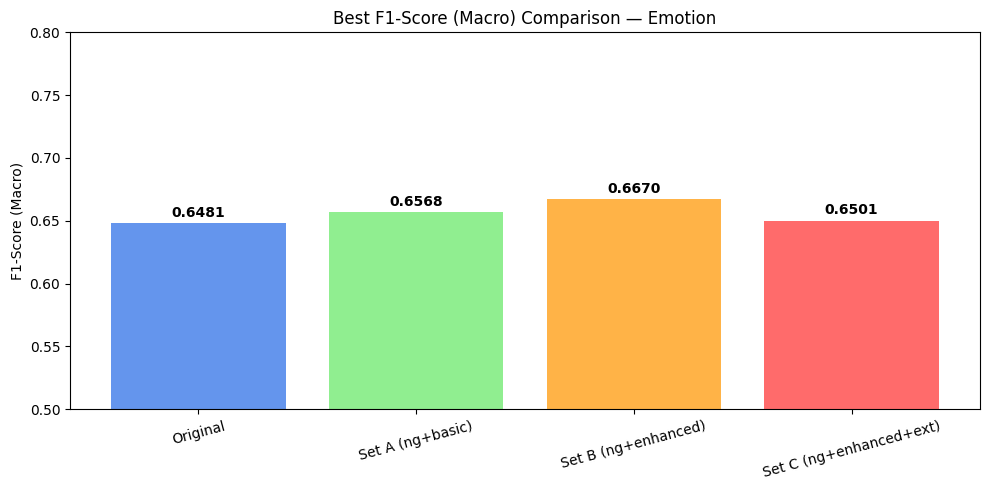

In [ ]:

# Sentiment — Best configuration per algorithm

print("=" * 90)
print("SENTIMENT — Ranked by F1-Score (Macro)")
print("=" * 90)
sentiment_ranked = df_results_sentiment.sort_values("F1-Score (Macro)", ascending=False).reset_index(drop=True)
display(sentiment_ranked)


# Emotion — Best configuration per algorithm

print("\n" + "=" * 90)
print("EMOTION — Ranked by F1-Score (Macro)")
print("=" * 90)
emotion_ranked = df_results_emotion.sort_values("F1-Score (Macro)", ascending=False).reset_index(drop=True)
display(emotion_ranked)


# Pivot Tables — Factorial Analysis

print("\n" + "=" * 90)
print("FACTORIAL ANALYSIS — F1-Score (Macro) per Faktor")
print("=" * 90)

# Sentiment — pivot
print("\n--- Sentiment: F1-Score (Macro) ---")
sent_pivot = df_results_sentiment.pivot_table(
    index='Algoritma', columns=['Varian', 'Imbalance'],
    values='F1-Score (Macro)', aggfunc='first'
)
display(sent_pivot)

# Emotion — pivot
print("\n--- Emotion: F1-Score (Macro) ---")
emo_pivot = df_results_emotion.pivot_table(
    index='Algoritma', columns=['Varian', 'Imbalance'],
    values='F1-Score (Macro)', aggfunc='first'
)
display(emo_pivot)


# Best Overall Models

print("\n" + "=" * 90)
print("BEST OVERALL MODELS")
print("=" * 90)

best_sent = sentiment_ranked.iloc[0]
print(f"\n>>> SENTIMENT <<<")
print(f"  Model:      {best_sent['Algoritma']}")
print(f"  Varian:     {best_sent['Varian']}")
print(f"  Imbalance:  {best_sent['Imbalance']}")
print(f"  Best Params: {best_sent['Best Params']}")
print(f"  CV Score:   {best_sent['CV Score']}")
print(f"  Accuracy:   {best_sent['Accuracy']}")
print(f"  Precision:  {best_sent['Precision (Macro)']}")
print(f"  Recall:     {best_sent['Recall (Macro)']}")
print(f"  F1 (Macro): {best_sent['F1-Score (Macro)']}")
print(f"  Infer Time: {best_sent['Inference Time (s)']}s")

best_emo = emotion_ranked.iloc[0]
print(f"\n>>> EMOTION <<<")
print(f"  Model:      {best_emo['Algoritma']}")
print(f"  Varian:     {best_emo['Varian']}")
print(f"  Imbalance:  {best_emo['Imbalance']}")
print(f"  Best Params: {best_emo['Best Params']}")
print(f"  CV Score:   {best_emo['CV Score']}")
print(f"  Accuracy:   {best_emo['Accuracy']}")
print(f"  Precision:  {best_emo['Precision (Macro)']}")
print(f"  Recall:     {best_emo['Recall (Macro)']}")
print(f"  F1 (Macro): {best_emo['F1-Score (Macro)']}")
print(f"  Infer Time: {best_emo['Inference Time (s)']}s")


# Visualization

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Sentiment F1 by Algorithm & Variant
sent_f1 = df_results_sentiment.pivot_table(
    index='Algoritma', columns=['Varian', 'Imbalance'],
    values='F1-Score (Macro)', aggfunc='first'
)
sent_f1.plot(kind='bar', ax=axes[0, 0], colormap='Set2', width=0.8)
axes[0, 0].set_title('Sentiment — F1-Score (Macro) per Konfigurasi')
axes[0, 0].set_ylabel('F1-Score (Macro)')
axes[0, 0].legend(title='Varian, SMOTE', fontsize=8)
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45, ha='right')

# 2. Emotion F1 by Algorithm & Variant
emo_f1 = df_results_emotion.pivot_table(
    index='Algoritma', columns=['Varian', 'Imbalance'],
    values='F1-Score (Macro)', aggfunc='first'
)
emo_f1.plot(kind='bar', ax=axes[0, 1], colormap='Set2', width=0.8)
axes[0, 1].set_title('Emotion — F1-Score (Macro) per Konfigurasi')
axes[0, 1].set_ylabel('F1-Score (Macro)')
axes[0, 1].legend(title='Varian, SMOTE', fontsize=8)
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right')

# 3. Sentiment — Inference Time
sent_time = df_results_sentiment.pivot_table(
    index='Algoritma', columns=['Varian', 'Imbalance'],
    values='Inference Time (s)', aggfunc='first'
)
sent_time.plot(kind='bar', ax=axes[1, 0], colormap='Set2', width=0.8)
axes[1, 0].set_title('Sentiment — Inference Time per Konfigurasi')
axes[1, 0].set_ylabel('Time (s)')
axes[1, 0].legend(title='Varian, Imbalance', fontsize=8)
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right')

# 4. Emotion — Inference Time
emo_time = df_results_emotion.pivot_table(
    index='Algoritma', columns=['Varian', 'Imbalance'],
    values='Inference Time (s)', aggfunc='first'
)
emo_time.plot(kind='bar', ax=axes[1, 1], colormap='Set2', width=0.8)
axes[1, 1].set_title('Emotion — Inference Time per Konfigurasi')
axes[1, 1].set_ylabel('Time (s)')
axes[1, 1].legend(title='Varian, Imbalance', fontsize=8)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()
print("\n" + "=" * 90)
print("PERBANDINGAN EMOTION: ORIGINAL vs IMPROVED")
print("=" * 90)

# Best F1-Macro from each set
best_original = df_results_emotion['F1-Score (Macro)'].max()
best_set_a = df_results_emo_ng5['F1-Score (Macro)'].max()
best_set_b = df_results_emo_ng15_base['F1-Score (Macro)'].max()
best_set_c = df_results_emo_ng15_ext['F1-Score (Macro)'].max()

comparison = pd.DataFrame({
    'Set': ['Original', 'Set A (ng+basic)', 'Set B (ng+enhanced)', 'Set C (ng+enhanced+ext)'],
    'Best F1-Macro': [best_original, best_set_a, best_set_b, best_set_c]
})
display(comparison)

# Also compare best from each algorithm across all sets
print("\n--- Best per Algorithm (across all configurations) ---")
all_emo_dfs = {
    'Original': df_results_emotion,
    'Set A': df_results_emo_ng5,
    'Set B': df_results_emo_ng15_base,
    'Set C': df_results_emo_ng15_ext
}
for set_name, df_set in all_emo_dfs.items():
    best_row = df_set.loc[df_set['F1-Score (Macro)'].idxmax()]
    print(f"\n{set_name}:")
    print(f"  {best_row['Algoritma']:20s} | {best_row['Varian']:10s} | {best_row['Imbalance']:8s} | F1: {best_row['F1-Score (Macro)']:.4f}")

# Visualization: compare best F1 across sets
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(comparison['Set'], comparison['Best F1-Macro'], color=['#6495ED', '#90EE90', '#FFB347', '#FF6B6B'])
ax.set_title('Best F1-Score (Macro) Comparison — Emotion')
ax.set_ylabel('F1-Score (Macro)')
ax.set_ylim(0.5, 0.8)
for i, v in enumerate(comparison['Best F1-Macro']):
    ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


TOP 2 SENTIMENT MODELS — Classification Report & Confusion Matrix

>>> Rank #1: Naive Bayes | Varian A | SMOTE: Ya
Best Params: {'alpha': 0.01}
F1-Score (Macro): 0.8897

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89       557
    Positive       0.89      0.89      0.89       523

    accuracy                           0.89      1080
   macro avg       0.89      0.89      0.89      1080
weighted avg       0.89      0.89      0.89      1080



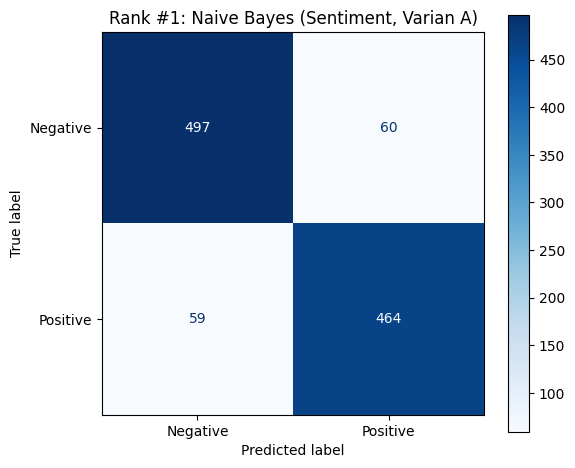


>>> Rank #2: Naive Bayes | Varian A | SMOTE: Tidak
Best Params: {'alpha': 0.01}
F1-Score (Macro): 0.8897

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.90      0.89       557
    Positive       0.89      0.88      0.89       523

    accuracy                           0.89      1080
   macro avg       0.89      0.89      0.89      1080
weighted avg       0.89      0.89      0.89      1080



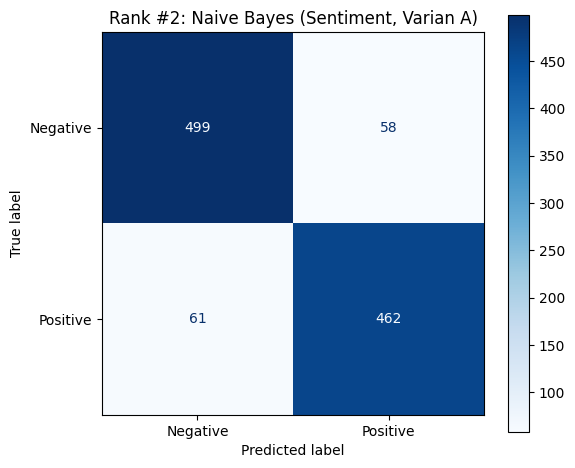


TOP 2 EMOTION MODELS — Classification Report & Confusion Matrix

>>> Rank #1: Logistic Regression | Varian C | SMOTE: Ya
Best Params: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
F1-Score (Macro): 0.6481

Classification Report:
              precision    recall  f1-score   support

       Anger       0.57      0.47      0.52       145
        Fear       0.44      0.61      0.51       159
       Happy       0.85      0.85      0.85       356
        Love       0.69      0.69      0.69       167
     Sadness       0.73      0.62      0.67       253

    accuracy                           0.69      1080
   macro avg       0.66      0.65      0.65      1080
weighted avg       0.70      0.69      0.69      1080



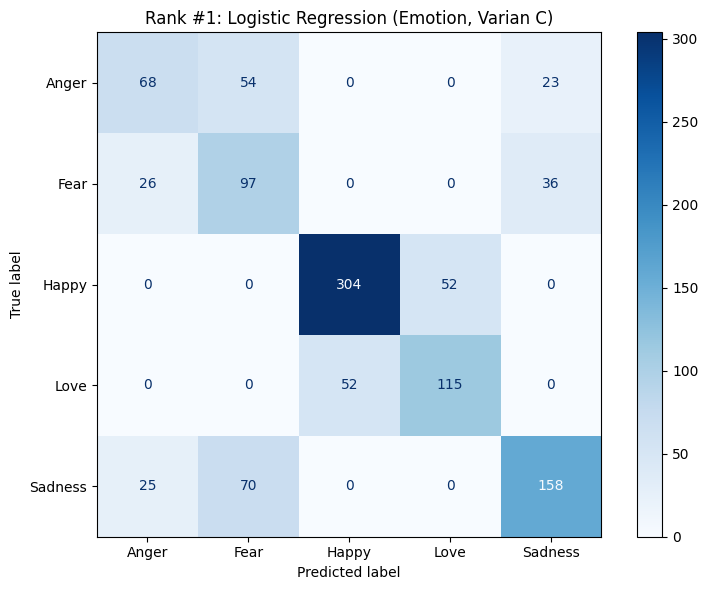


>>> Rank #2: Logistic Regression | Varian C | SMOTE: Tidak
Best Params: {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}
F1-Score (Macro): 0.632

Classification Report:
              precision    recall  f1-score   support

       Anger       0.58      0.39      0.46       145
        Fear       0.45      0.50      0.47       159
       Happy       0.83      0.91      0.87       356
        Love       0.75      0.60      0.67       167
     Sadness       0.65      0.72      0.69       253

    accuracy                           0.69      1080
   macro avg       0.65      0.62      0.63      1080
weighted avg       0.69      0.69      0.68      1080



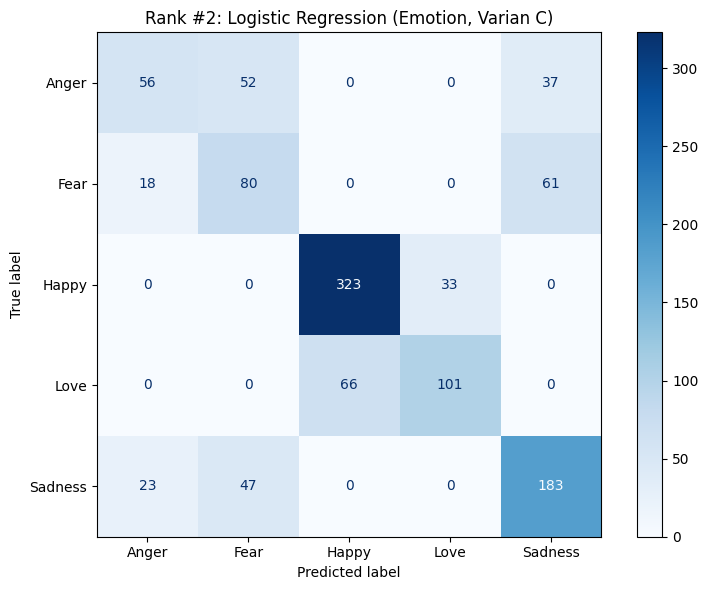

In [ ]:

# Top 2 Sentiment Models — Classification Report & Confusion Matrix

print("=" * 70)
print("TOP 2 SENTIMENT MODELS — Classification Report & Confusion Matrix")
print("=" * 70)

sent_var_map = {'A': X_test_a, 'B': X_test_b}

for rank in [0, 1]:
    row = sentiment_ranked.iloc[rank]
    use_smote = row['Imbalance'] in ['SMOTE', 'Ya']
    key = (row['Algoritma'], row['Varian'], use_smote)
    info = best_models_sentiment[key]
    est = info['best_estimator']
    pred = info['y_pred']
    X_te = sent_var_map[row['Varian']]

    print(f"\n>>> Rank #{rank+1}: {row['Algoritma']} | Varian {row['Varian']} | {row['Imbalance']}")
    print(f"Best Params: {row['Best Params']}")
    print(f"F1-Score (Macro): {row['F1-Score (Macro)']}")
    print(f"\nClassification Report:")
    print(classification_report(y_test_sen, pred))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_estimator(est, X_te, y_test_sen, ax=ax, cmap="Blues", values_format='d')
    ax.set_title(f"Rank #{rank+1}: {row['Algoritma']} (Sentiment, Varian {row['Varian']})")
    plt.tight_layout()
    plt.show()


# Top 2 Emotion Models — Classification Report & Confusion Matrix

print("\n" + "=" * 70)
print("TOP 2 EMOTION MODELS — Classification Report & Confusion Matrix")
print("=" * 70)

emo_var_map = {'A': X_test_a, 'B': X_test_b, 'C': X_test_c}

for rank in [0, 1]:
    row = emotion_ranked.iloc[rank]
    use_smote = row['Imbalance'] in ['SMOTE', 'Ya']
    key = (row['Algoritma'], row['Varian'], use_smote)
    info = best_models_emotion[key]
    est = info['best_estimator']
    pred = info['y_pred']
    X_te = emo_var_map[row['Varian']]

    print(f"\n>>> Rank #{rank+1}: {row['Algoritma']} | Varian {row['Varian']} | {row['Imbalance']}")
    print(f"Best Params: {row['Best Params']}")
    print(f"F1-Score (Macro): {row['F1-Score (Macro)']}")
    print(f"\nClassification Report:")
    print(classification_report(y_test_emo, pred))

    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_estimator(est, X_te, y_test_emo, ax=ax, cmap="Blues", values_format='d')
    ax.set_title(f"Rank #{rank+1}: {row['Algoritma']} (Emotion, Varian {row['Varian']})")
    plt.tight_layout()
    plt.show()

In [37]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# 1. Best Sentiment Model
best_sent_row = sentiment_ranked.iloc[0]
use_smote = best_sent_row['Imbalance'] in ['SMOTE', 'Ya']
best_sent_key = (best_sent_row['Algoritma'], best_sent_row['Varian'], use_smote)
best_sent_est = best_models_sentiment[best_sent_key]['best_estimator']

joblib.dump(best_sent_est, 'models/best_sentiment_model.joblib')
joblib.dump(vectorizer, 'models/sentiment_vectorizer.joblib')

print(f"Sentiment model saved: {best_sent_row['Algoritma']} (F1={best_sent_row['F1-Score (Macro)']})")

# 2. Best Emotion Model
all_emo_dfs = {
    'Original': df_results_emotion,
    'Set A':    df_results_emo_ng5,
    'Set B':    df_results_emo_ng15_base,
    'Set C':    df_results_emo_ng15_ext,
}
best_emo_overall = None
best_f1 = -1
best_set_name = ''
for set_name, df_set in all_emo_dfs.items():
    row = df_set.loc[df_set['F1-Score (Macro)'].idxmax()]
    if row['F1-Score (Macro)'] > best_f1:
        best_f1 = row['F1-Score (Macro)']
        best_emo_overall = row
        best_set_name = set_name

emo_dict_map = {
    'Original': best_models_emotion,
    'Set A':    best_emo_ng5,
    'Set B':    best_emo_ng15_base,
    'Set C':    best_emo_ng15_ext,
}
if best_set_name in ('Original', 'Set A'):
    # Dict key uses boolean (use_smote)
    use_smote = best_emo_overall['Imbalance'] in ('SMOTE', 'Ya')
    best_emo_key = (best_emo_overall['Algoritma'], best_emo_overall['Varian'], use_smote)
else:
    # Dict key uses lowercase string ('none', 'smote', 'adasyn')
    imb_key = best_emo_overall['Imbalance'].lower()
    imb_key = {'tidak': 'none', 'ya': 'smote'}.get(imb_key, imb_key)
    best_emo_key = (best_emo_overall['Algoritma'], best_emo_overall['Varian'], imb_key)

best_emo_est = emo_dict_map[best_set_name][best_emo_key]['best_estimator']

joblib.dump(best_emo_est, 'models/best_emotion_model.joblib')
joblib.dump(vectorizer_ng, 'models/emotion_vectorizer_ngram.joblib')

print(f"Emotion model saved: {best_emo_overall['Algoritma']} ({best_set_name}, F1={best_f1})")

Sentiment model saved: Naive Bayes (F1=0.8897)
Emotion model saved: Logistic Regression (Set B, F1=0.667)
